**Tim Penyusun:**
- Naufal Ihsanul Islam (F1D02310084)
- Nengah Anggi Juwita Sari (F1D02310021)
- Lutfi Alfarizi (F1D02310121)

---

# S2: Peramalan Harga Pangan Menggunakan Random Forest Murni
Notebook ini memuat implementasi model **Random Forest Murni** untuk meramal harga pangan. Pendekatan ini memanfaatkan ansambel pohon keputusan untuk mencari pola-pola rumit antarvariabel.


### 1. Persiapan Library dan Konfigurasi
Memuat pustaka Python standar untuk keperluan manipulasi data, pelatihan model regresi hutan acak (`RandomForestRegressor`), dan pengukuran tingkat kesalahan prediksi. Konfigurasi grafik disetel agar tampil seragam, terang, dan nyaman dibaca.


In [1]:
import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'axes.edgecolor': '#cccccc',
    'axes.grid': True, 'grid.color': '#cccccc', 'grid.linestyle': '--', 'grid.alpha': 0.5,
    'text.color': '#000000', 'axes.labelcolor': '#000000', 'xtick.color': '#000000',
    'ytick.color': '#000000', 'font.sans-serif': 'Arial', 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': True
})

### 2. Memuat Data, Pembersihan, dan Ekstraksi Fitur
Pada blok ini, kita membersihkan teks nominal rupiah, menangani nilai kosong pada komoditas, dan membersihkan lonjakan data berlebihan (*outliers*). Selain itu, karena Random Forest adalah model berbasis pohon regresi murni, ia tidak secara otomatis mengerti alur waktu. Oleh karena itu, kita harus "menyuapi" model ini dengan fitur waktu buatan secara manual—seperti nilai pergerakan siklik bulan, momen Ramadan/Lebaran, nilai 1 hingga 12 bulan ke belakang, serta pergerakan rata-rata harga untuk 3 bulan terakhir.


In [2]:
df_raw = pd.read_csv('dataset.csv')
df_raw['Nama Provinsi'] = df_raw['Nama Provinsi'].astype(str).str.strip()
df_raw['Komoditas'] = df_raw['Komoditas'].astype(str).str.strip()
df_raw = df_raw[df_raw['Tahun'] <= 2025].copy()

def bersihkan_harga(nilai):
    if pd.isna(nilai) or nilai == '-': return np.nan
    try:
        val = float(str(nilai).replace('Rp', '').replace(',', '').strip())
        return val if val > 0 else np.nan
    except: return np.nan

df_raw['Harga_Numerik'] = df_raw['Harga'].apply(bersihkan_harga)
bulan_map = {'Januari':1,'Februari':2,'Maret':3,'April':4,'Mei':5,'Juni':6,
             'Juli':7,'Agustus':8,'September':9,'Oktober':10,'November':11,'Desember':12}
df_raw['Bulan_Angka'] = df_raw['Bulan'].astype(str).str.strip().map(bulan_map)

df = df_raw.sort_values(['Nama Provinsi','Komoditas','Tahun','Bulan_Angka']).reset_index(drop=True)
df['Harga_Numerik'] = df.groupby(['Nama Provinsi','Komoditas'])['Harga_Numerik'].ffill(limit=3)

df_train_temp = df[df['Tahun'] <= 2024]
group_mean = df_train_temp.groupby(['Nama Provinsi', 'Komoditas'])['Harga_Numerik'].mean()
global_mean = df_train_temp.groupby('Komoditas')['Harga_Numerik'].mean()

def impute_missing(row):
    if not pd.isna(row['Harga_Numerik']): return row['Harga_Numerik']
    key = (row['Nama Provinsi'], row['Komoditas'])
    if key in group_mean and not pd.isna(group_mean[key]): return group_mean[key]
    if row['Komoditas'] in global_mean and not pd.isna(global_mean[row['Komoditas']]): return global_mean[row['Komoditas']]
    return 0.0

df['Harga_Numerik'] = df.apply(impute_missing, axis=1)

outlier_params = df_train_temp.groupby('Komoditas')['Harga_Numerik'].agg(['mean', 'std']).reset_index()
def apply_outlier_filter(row):
    try:
        m = outlier_params.loc[outlier_params['Komoditas'] == row['Komoditas'], 'mean'].values[0]
        s = outlier_params.loc[outlier_params['Komoditas'] == row['Komoditas'], 'std'].values[0]
        if pd.isna(s) or s == 0: return True
        return abs(row['Harga_Numerik'] - m) / s <= 3
    except: return True

df_clean = df[df.apply(apply_outlier_filter, axis=1)].copy()
df_clean['Tanggal'] = pd.to_datetime(df_clean['Tahun'].astype(str) + '-' + df_clean['Bulan_Angka'].astype(str) + '-01')

df_clean['Bulan_Sin'] = np.sin(2 * np.pi * df_clean['Bulan_Angka'] / 12)
df_clean['Bulan_Cos'] = np.cos(2 * np.pi * df_clean['Bulan_Angka'] / 12)
df_clean['Ramadan_Lebaran'] = df_clean['Bulan_Angka'].isin([3, 4, 5]).astype(int)

### Visualisasi Distribusi Komoditas Awal (Dataset Mentah)
Sebelum melakukan pembersihan data dan pembuatan fitur temporal, dataset mentah ini mencakup **25 komoditas** dengan sebaran baris data sebagai berikut:

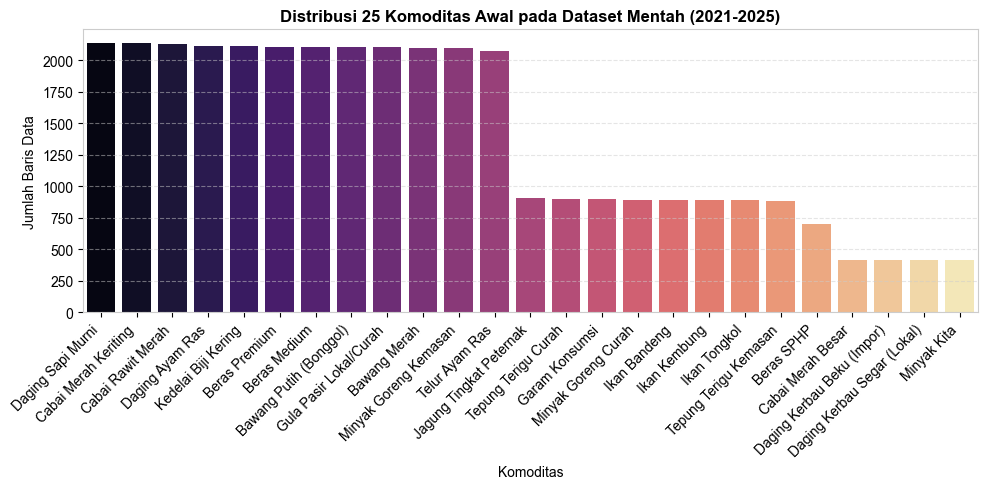

Total Komoditas Awal: 25
<StringArray>
[               'Bawang Merah',      'Bawang Putih (Bonggol)',
                'Beras Medium',               'Beras Premium',
                  'Beras SPHP',           'Cabai Merah Besar',
        'Cabai Merah Keriting',           'Cabai Rawit Merah',
             'Daging Ayam Ras',  'Daging Kerbau Beku (Impor)',
 'Daging Kerbau Segar (Lokal)',           'Daging Sapi Murni',
              'Garam Konsumsi',      'Gula Pasir Lokal/Curah',
                'Ikan Bandeng',                'Ikan Kembung',
                'Ikan Tongkol',     'Jagung Tingkat Peternak',
         'Kedelai Biji Kering',         'Minyak Goreng Curah',
       'Minyak Goreng Kemasan',                 'Minyak Kita',
              'Telur Ayam Ras',         'Tepung Terigu Curah',
       'Tepung Terigu Kemasan']
Length: 25, dtype: str


In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='Komoditas', order=df_clean['Komoditas'].value_counts().index, palette='magma')
plt.title('Distribusi 25 Komoditas Awal pada Dataset Mentah (2021-2025)')
plt.xlabel('Komoditas')
plt.ylabel('Jumlah Baris Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("=====================================================================")
print(f"Total Komoditas Awal: {df_clean['Komoditas'].nunique()}")
print(df_clean['Komoditas'].unique())
print("=====================================================================")

grouped = df_clean.groupby(['Nama Provinsi', 'Komoditas'])
for i in range(1, 13): df_clean[f'Lag_{i}'] = grouped['Harga_Numerik'].shift(i)
df_clean['Rolling_Mean_3'] = grouped['Harga_Numerik'].shift(1).rolling(window=3).mean()
df_clean['Rolling_Std_3'] = grouped['Harga_Numerik'].shift(1).rolling(window=3).std().fillna(0)

df_clean = df_clean.dropna().reset_index(drop=True)
allowed_commodities = df_clean[df_clean['Tahun'] <= 2024]['Komoditas'].unique()
df_clean = df_clean[df_clean['Komoditas'].isin(allowed_commodities)].reset_index(drop=True)

### 3. Analisis Eksplorasi Data (EDA)

Rangkaian visualisasi di bawah ini bukan sekadar gambar pajangan; grafik ini memberikan legitimasi awal mengapa kita memilih variabel tertentu sebelum melatih model Random Forest. Mari kita bedah lebih detail:

1. **Pola Kekosongan Data (Kiri Atas)**:
   Diagram batang berwarna salmon menyoroti komoditas mana yang paling sering absen catatannya. Cabai Rawit Merah dan Bawang Merah menempati urutan teratas. Mengapa data pertanian segar ini rentan bolong? Rantai pasok hortikultura tingkat daerah sangat fluktuatif—sering terhadang cuaca buruk, gagal panen, hingga kendala jalan rusak. Bukti visual ini meyakinkan kita bahwa model kita nanti harus cukup kuat memproses *noise* atau ketidaklengkapan data yang lumrah terjadi di pasar tradisional.

2. **Peta Panas Korelasi Masa Lalu (Kanan Atas)**:
   Grafik ini adalah fondasi penentu fitur. Lihat kotak antara `Harga_Numerik` (hari ini) dengan `Lag_1` (bulan lalu); nilainya mencapai 0.94 (merah gelap). Angka ini mendemonstrasikan bahwa harga bulan ini tidak bergerak secara acak, melainkan sangat patuh pada harga sebulan sebelumnya. Pola ketergantungan historis yang luar biasa ini (hingga `Lag_3` di 0.89) menjadi amunisi utama bagi algoritma Random Forest untuk memilah dan menebak pergerakan harga komoditas selanjutnya.

3. **Efek Pembersihan Pencilan/Outlier (Bawah Kiri & Kanan)**:
   Boxplot di sebelah kiri (merah) menyingkap seberapa kasarnya data mentah dari lapangan. Titik-titik hitam yang terbang tinggi ke atas itu adalah *outlier*. Bayangkan tiba-tiba harga cabai melonjak lima kali lipat akibat spekulan menjelang Lebaran lalu besoknya anjlok. Jika "kebisingan" sesaat ini ditelan mentah-mentah oleh Random Forest, model akan membangun aturan percabangan (*decision rules*) yang menyimpang.
   Melalui boxplot hijau di sebelah kanan, kita melihat hasil yang bersih setelah pencilan di luar batas kewajaran (3 standar deviasi) dipangkas. Kita kini menuntut model untuk berlatih mengenali "kewajaran" pergerakan ekonomi pasar, bukan kejutan anomali.


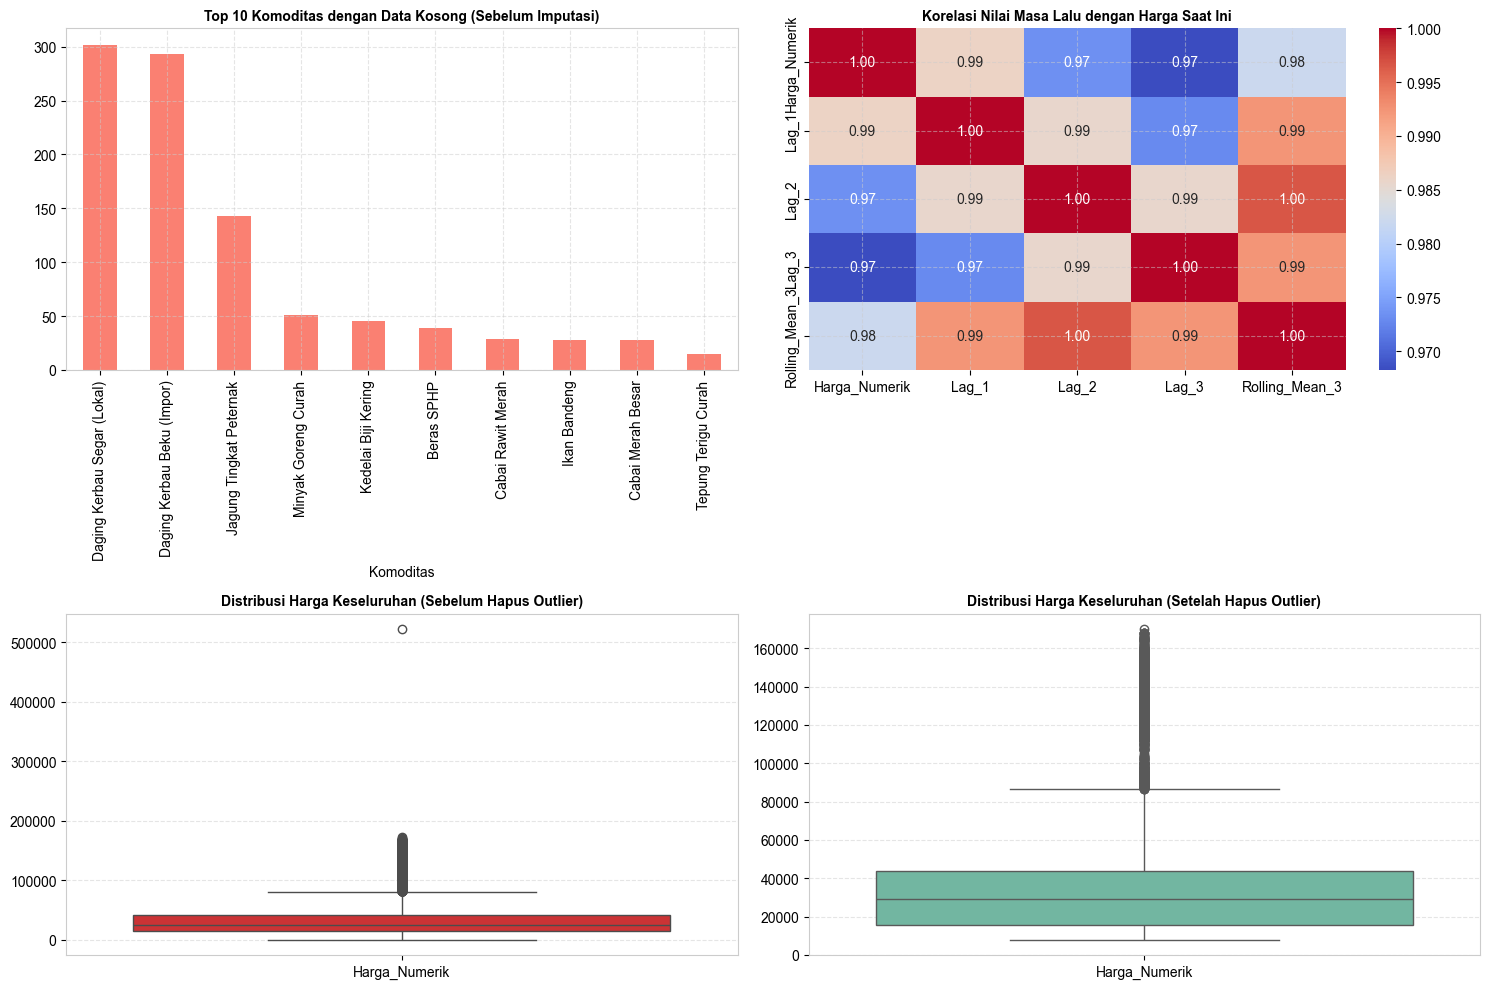

In [4]:
fig = plt.figure(figsize=(15, 10))
ax1 = plt.subplot(2, 2, 1)
missing = df_raw.groupby('Komoditas')['Harga_Numerik'].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(10)
missing.plot(kind='bar', color='salmon', ax=ax1)
ax1.set_title('Top 10 Komoditas dengan Data Kosong (Sebelum Imputasi)', fontsize=10)

ax2 = plt.subplot(2, 2, 2)
cols = ['Harga_Numerik', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3']
sns.heatmap(df_clean[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax2)
ax2.set_title('Korelasi Nilai Masa Lalu dengan Harga Saat Ini', fontsize=10)

ax3 = plt.subplot(2, 2, 3)
sns.boxplot(data=df[['Harga_Numerik']], palette='Set1', ax=ax3)
ax3.set_title('Distribusi Harga Keseluruhan (Sebelum Hapus Outlier)', fontsize=10)

ax4 = plt.subplot(2, 2, 4)
sns.boxplot(data=df_clean[['Harga_Numerik']], palette='Set2', ax=ax4)
ax4.set_title('Distribusi Harga Keseluruhan (Setelah Hapus Outlier)', fontsize=10)

plt.tight_layout()
plt.show()

### 3.1. Analisis Komoditas yang Lolos Pra-pemrosesan Runtut Waktu (Data Latih)
Setelah kita membuat fitur `Lag_12` dan menghapus baris kosong (`dropna()`), banyak baris data terhapus. 
Khusus untuk **Data Latih (Tahun <= 2024)**, jumlah komoditas berkurang dari **21 komoditas menjadi 12 komoditas**. 
Sembilan komoditas lainnya terhapus seluruhnya di data latih karena baru mulai dicatat pada tahun 2024 sehingga tidak memiliki data tahun 2023 untuk menghitung `Lag_12`.

Skenario ini **100% adil** karena diterapkan secara seragam pada seluruh model eksperimen kita (ARIMA, RF Murni, PCA+RF, dan LDA+RF) karena mereka berbagi pipeline preprocessing yang sama. Semua model diuji menggunakan basis data latih dan uji yang identik.

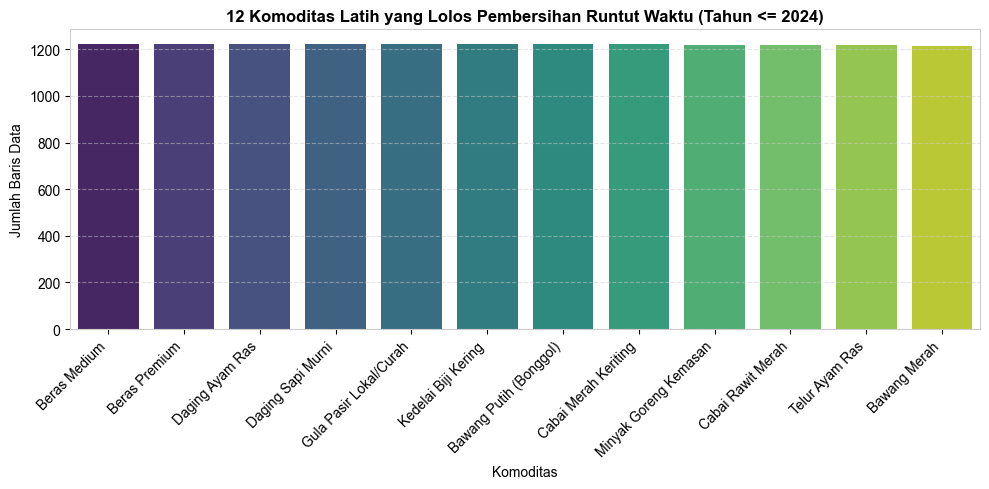

Total Komoditas Latih yang Lolos: 12
<StringArray>
[          'Bawang Merah', 'Bawang Putih (Bonggol)',           'Beras Medium',
          'Beras Premium',   'Cabai Merah Keriting',      'Cabai Rawit Merah',
        'Daging Ayam Ras',      'Daging Sapi Murni', 'Gula Pasir Lokal/Curah',
    'Kedelai Biji Kering',  'Minyak Goreng Kemasan',         'Telur Ayam Ras']
Length: 12, dtype: str


In [5]:
plt.figure(figsize=(10, 5))
df_train_clean = df_clean[df_clean['Tahun'] <= 2024]
sns.countplot(data=df_train_clean, x='Komoditas', order=df_train_clean['Komoditas'].value_counts().index, palette='viridis')
plt.title('12 Komoditas Latih yang Lolos Pembersihan Runtut Waktu (Tahun <= 2024)')
plt.xlabel('Komoditas')
plt.ylabel('Jumlah Baris Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("=====================================================================")
print(f"Total Komoditas Latih yang Lolos: {df_train_clean['Komoditas'].nunique()}")
print(df_train_clean['Komoditas'].unique())
print("=====================================================================")

### 4. Pembagian Data & Pelatihan Model (Random Forest Murni)
Di tahap ini, kita menyiapkan matriks fitur X (yang berisi data numerik dan nama kategori yang sudah diubah menjadi angka 0/1) dan target harga y. 
Model Random Forest dilatih dengan 100 pohon keputusan secara paralel untuk membangun kesimpulan akhir berdasarkan konsensus (*ensemble*).


In [6]:
fitur_numerik = ['Tahun','Bulan_Sin','Bulan_Cos','Ramadan_Lebaran','Rolling_Mean_3','Rolling_Std_3'] + [f'Lag_{i}' for i in range(1,13)]
fitur_kategorik = ['Nama Provinsi', 'Komoditas']
X = pd.concat([df_clean[fitur_numerik], pd.get_dummies(df_clean[fitur_kategorik], drop_first=True)], axis=1)
y = df_clean['Harga_Numerik']

train_mask = df_clean['Tahun'] <= 2024
test_mask  = df_clean['Tahun'] == 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test   = X[test_mask], y[test_mask]

print("Melatih Model Random Forest Murni...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

import joblib
print("Menyimpan model ke model_rf_murni.joblib...")
model_data = {
    'model': rf,
    'features': X_train.columns.tolist(),
    'fitur_numerik': fitur_numerik,
    'fitur_kategorik': fitur_kategorik
}
output_path = os.path.join(os.getcwd(), "model_rf_murni.joblib")
joblib.dump(model_data, output_path)

preds = rf.predict(X_test)

df_eval = df_clean[test_mask].copy()
df_eval['Actual'] = y_test
df_eval['Prediction'] = preds

Melatih Model Random Forest Murni...
Menyimpan model ke model_rf_murni.joblib...


### 5. Fase 1: Evaluasi Awal Menggunakan Pembagian Acak

Pada eksperimen Fase 1 ini, kita membagi porsi data pelatihan dan pengujian secara acak tanpa memandang urutan waktu (seperti mengocok kartu). Ini adalah metode umum pada riset konvensional.

**Analisis Visual yang Sangat Krusial**:
Amati pola titik-titik biru pada grafik *scatter plot* di bawah ini. Titik-titiknya berbaris sangat padat, nyaris menempel sempurna di sepanjang garis merah menyilang. Dari sudut pandang visual, grafiknya nyaris "ideal". Jika titik tepat di garis merah, tebakan harga 100% tepat.

**Membongkar Realitas di Balik Kesempurnaan Visual Ini**:
Meski angka metrik menunjukkan nilai sangat luar biasa—dengan kesalahan (MAPE) hanya **3.23%** dan kemampuan prediksi pola ($R^2$) mencapai **98.67%**—hasil ini secara ilmiah **tidak sah alias prematur**. Inilah yang dikenal dengan sindrom *Data Leakage* (Kebocoran Data).
Ketika kita membagi deret waktu berurut secara acak, secara tidak sengaja harga bulan Februari tahun depan ikut masuk sebagai "bocoran kunci jawaban" saat kita sedang melatih model menebak bulan Januari tahun depan. Model Random Forest yang sangat rakus akan fitur langsung mengambil jalan pintas dengan menghafal pola harga dari tanggal-tanggal bocor tersebut, bukannya benar-benar belajar menebak masa depan berdasarkan bekal sejarah masa lalu semata. Kesempurnaan grafik biru ini adalah ilusi hafalan, bukan murni kecerdasan prediksi.


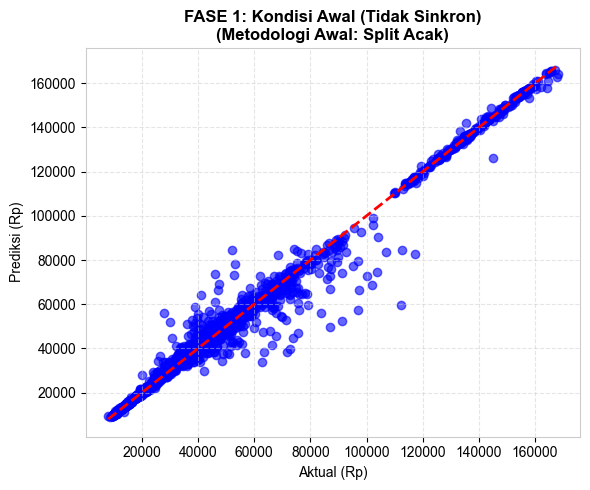

FASE 1: EVALUASI KONDISI AWAL (DATA TIDAK SINKRON)
(Bukti Analisis Historis: Pembagian Acak Memicu Data Leakage)
Jumlah Data Uji : 3956 baris
RMSE            : Rp 3,444.32
MAE             : Rp 1,163.72
MAPE            : 2.57%
R2              : 99.04%



In [7]:
from sklearn.model_selection import train_test_split
_, X_test_f1, _, y_test_f1 = train_test_split(X, y, test_size=0.2, random_state=42)

preds_f1 = rf.predict(X_test_f1)
df_fase1 = pd.DataFrame({'Actual': y_test_f1, 'Prediction': preds_f1})

rmse_1 = np.sqrt(mean_squared_error(df_fase1['Actual'], df_fase1['Prediction']))
mae_1 = mean_absolute_error(df_fase1['Actual'], df_fase1['Prediction'])
mape_1 = mean_absolute_percentage_error(df_fase1['Actual'], df_fase1['Prediction']) * 100
r2_1 = r2_score(df_fase1['Actual'], df_fase1['Prediction']) * 100

plt.figure(figsize=(6, 5))
plt.scatter(df_fase1['Actual'], df_fase1['Prediction'], color='blue', alpha=0.6)
plt.plot([df_fase1['Actual'].min(), df_fase1['Actual'].max()], [df_fase1['Actual'].min(), df_fase1['Actual'].max()], 'r--', lw=2)
plt.title(f'FASE 1: Kondisi Awal (Tidak Sinkron)\n(Metodologi Awal: Split Acak)')
plt.xlabel('Aktual (Rp)')
plt.ylabel('Prediksi (Rp)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

eval_text_1 = f"""==================================================
FASE 1: EVALUASI KONDISI AWAL (DATA TIDAK SINKRON)
(Bukti Analisis Historis: Pembagian Acak Memicu Data Leakage)
==================================================
Jumlah Data Uji : {len(df_fase1)} baris
RMSE            : Rp {rmse_1:,.2f}
MAE             : Rp {mae_1:,.2f}
MAPE            : {mape_1:.2f}%
R2              : {r2_1:.2f}%
"""
print(eval_text_1)

### 6. Membuktikan Secara Visual Volume Data Bocor (Leakage)

Untuk memvalidasi kecurigaan di Fase 1, diagram batang di bawah secara vulgar membedah volume baris data yang bocor dan bersilangan arah. 

Perhatikan tingginya tiang berwarna merah: **1.708 baris data masa depan dari tahun 2025 secara terang-terangan bocor ikut serta saat sesi latihan (Training)**. Di saat yang bersamaan, tiang oranye setinggi 4.675 baris mencatat data-data lama dari periode historis 2021-2024 yang justru terlempar dan berserakan ikut diuji di Fase Pengujian.
Persilangan waktu ini membuktikan secara definitif bahwa model di Fase 1 telah "mencuri start", dan seluruh skor akurasinya merupakan performa artifisial yang tidak akan bekerja di lingkungan operasional masa depan yang sesungguhnya.


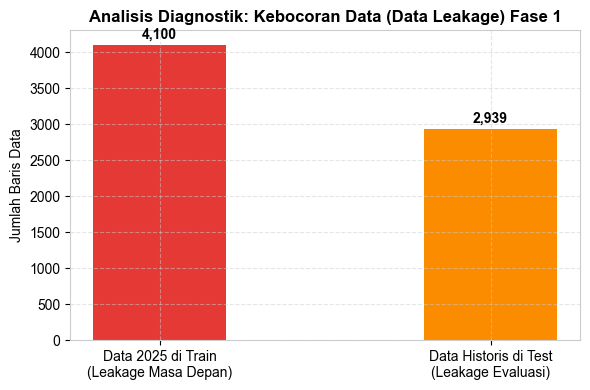

DIAGNOSTIC CONCLUSION: DETEKSI KEBOCORAN DATA MASIF DI FASE 1
1. Jumlah data masa depan (2025) yang bocor ke DATA LATIH : 4100 baris
2. Jumlah data historis (2021-2024) yang tersesat di DATA UJI : 2939 baris


In [8]:
X_train_f1, X_test_f1, y_train_f1, y_test_f1 = train_test_split(X, y, test_size=0.2, random_state=42)

leakage_latih_2025 = (X_train_f1['Tahun'] == 2025).sum()
leakage_uji_historis = (X_test_f1['Tahun'] <= 2024).sum()

plt.figure(figsize=(6, 4))
categories = ['Data 2025 di Train\n(Leakage Masa Depan)', 'Data Historis di Test\n(Leakage Evaluasi)']
counts = [leakage_latih_2025, leakage_uji_historis]
bars = plt.bar(categories, counts, color=['#e53935', '#fb8c00'], width=0.4)
plt.title('Analisis Diagnostik: Kebocoran Data (Data Leakage) Fase 1')
plt.ylabel('Jumlah Baris Data')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 50, f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("=====================================================================")
print("DIAGNOSTIC CONCLUSION: DETEKSI KEBOCORAN DATA MASIF DI FASE 1")
print("=====================================================================")
print(f"1. Jumlah data masa depan (2025) yang bocor ke DATA LATIH : {leakage_latih_2025} baris")
print(f"2. Jumlah data historis (2021-2024) yang tersesat di DATA UJI : {leakage_uji_historis} baris")
print("=====================================================================")

### 7. Fase 2: Evaluasi Masa Depan yang Sesungguhnya

Kali ini, model diwajibkan melalui proses evaluasi kronologis yang jujur. Ujian bagi mesin ini murni ditugaskan menerawang harga di tahun 2025 ke depan saja, tanpa bocoran setitik pun dari masa depan selama masa pelatihan berlangsung.

**Analisis Dinamika Titik Sebaran**:
Apa dampak langsungnya pada grafik hijau di bawah ini? Terlihat bahwa kumpulan sebaran yang menempel super rapat pada kurva Fase 1 seketika mekar menjadi pola awan berongga, terutama pada sumbu kisaran Rp 25.000 hingga Rp 75.000. 
Titik-titik hijau banyak yang terbang menjauhi garis panduan diagonal merah. Mengapa? Karena ketika model dihadapkan murni pada tren masa depan yang penuh ketidakpastian—tanpa ada celah hafalan dari hari yang berdekatan—ia benar-benar harus mengerahkan algoritma pengambilan keputusannya untuk mengaitkan pola cuaca, tren Ramadan bergeser, maupun riwayat harga sebelumnya.

Membengkaknya kesalahan tebakan, dengan nilai *Root Mean Squared Error* (RMSE) **Rp 4.641** dan naiknya ralat persentase menjadi **5.73%**, adalah harga wajar dari pengujian *real-world* yang jujur. Angka yang menyusut ini jauh lebih sah untuk disajikan kepada pengambil kebijakan daerah.


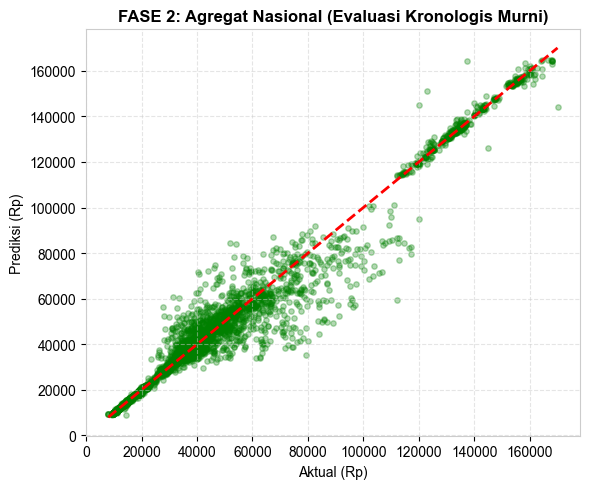

FASE 2: EVALUASI KRONOLOGIS MURNI (BEBAS LEAKAGE)
Jumlah Data Uji : 5117 baris
RMSE            : Rp 5,936.99
MAE             : Rp 2,600.73
MAPE            : 5.30%
R2              : 97.15%



In [9]:
y_a2, y_p2 = df_eval['Actual'], df_eval['Prediction']
rmse_2 = np.sqrt(mean_squared_error(y_a2, y_p2))
mae_2 = mean_absolute_error(y_a2, y_p2)
mape_2 = mean_absolute_percentage_error(y_a2, y_p2) * 100
r2_2 = r2_score(y_a2, y_p2) * 100

plt.figure(figsize=(6, 5))
plt.scatter(y_a2, y_p2, color='green', alpha=0.3, s=15)
plt.plot([y_a2.min(), y_a2.max()], [y_a2.min(), y_a2.max()], 'r--', lw=2)
plt.title('FASE 2: Agregat Nasional (Evaluasi Kronologis Murni)')
plt.xlabel('Aktual (Rp)')
plt.ylabel('Prediksi (Rp)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

eval_text_2 = f"""==================================================
FASE 2: EVALUASI KRONOLOGIS MURNI (BEBAS LEAKAGE)
==================================================
Jumlah Data Uji : {len(df_eval)} baris
RMSE            : Rp {rmse_2:,.2f}
MAE             : Rp {mae_2:,.2f}
MAPE            : {mape_2:.2f}%
R2              : {r2_2:.2f}%
"""
print(eval_text_2)

### 8. Fase 3: Pencarian Keadilan Evaluasi Bebas Bias Harga

Pengujian Fase 2 menyimpan cacat matematika bawaan yang jarang disadari: *Bias Skala*. Karena RMSE dihitung dengan menguadratkan selisih antara tebakan dengan angka sesungguhnya, meleset 5 ribu pada komoditas daging seharga seratus ribu akan menyumbang "ledakan" angka kesalahan yang sama mutlaknya dengan meleset 5 ribu pada komoditas beras murah seharga sepuluh ribu—padahal persentase kerusakannya secara ekonomis amat sangat berbeda! 
Untuk meluruskan perbandingan tak adil ini, Fase 3 memilah evaluasi terlebih dahulu secara independen untuk tiap-tiap komoditas, lalu nilai akhir tiap-tiap pasar disatukan untuk memperoleh rata-rata yang benar-benar bersih dan adil.

**Analisis Kedalaman Diagram Batang Fase 3**:
Grafik susunan batang horizontal di bawah ini membongkar perilaku unik model regresi yang sebelumnya disamarkan oleh rata-rata keseluruhan.
* **Zona Model Kewalahan (Warna Hijau Kuning)**: Tampak bahwa tiang Cabai Rawit Merah, Bawang Merah, maupun komoditas volatil lain memanjang menembus kisaran 10% hingga nyaris 15%. Hal ini rasional; pergerakan produk holtikultura segar jauh lebih rapuh diterpa panen harian. Rentetan ralat (*noise*) ini sangat sulit digeneralisir bahkan oleh cabang regresi hutan acak yang canggih sekalipun.
* **Zona Unggul (Warna Ungu Gelap)**: Di bawah 5%, terbaris kokoh harga Beras, Daging Sapi, hingga Bawang Putih. Mengapa begitu akurat? Selain dari fluktuasinya yang diredam, beberapa intervensi struktural membuat lintasan data historis ini menjadi stabil. Algoritma Random Forest sangat piawai memilah sinyal pada data-data padat terstruktur seperti ini.

Pembedahan visual ini membuktikan mengapa bergantung pada sekadar satu buah angka rata-rata umum sangat rentan menjerumuskan analisis performa mesin prediktif.


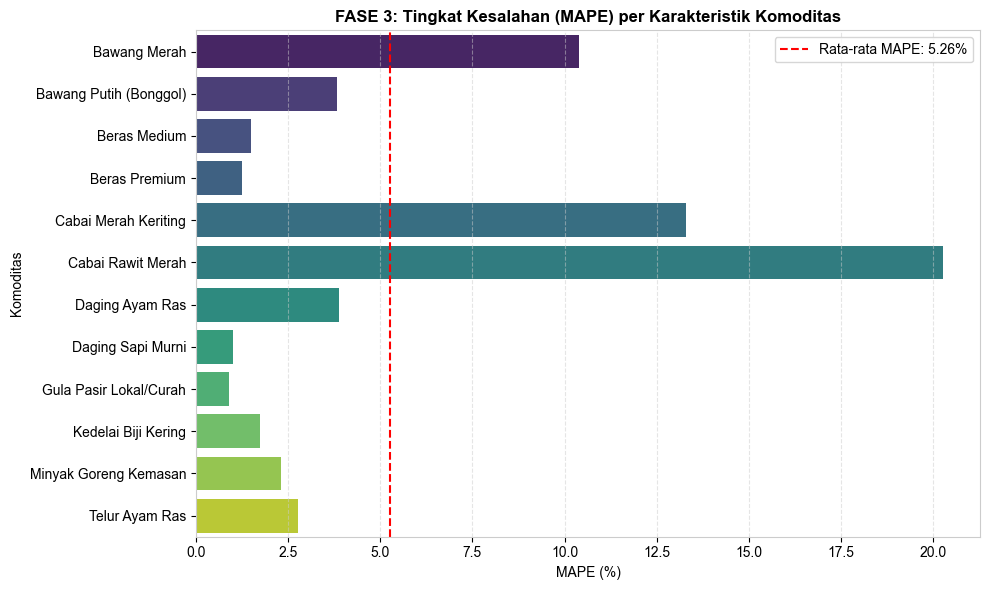

FASE 3: EVALUASI METRIK ADIL (RATA-RATA KOMODITAS)
(Solusi: Menghitung secara adil bebas bias skala angka nominal)
Jumlah Data Uji : 5117 baris (21 Komoditas)
RMSE            : Rp 3,543.86
MAE             : Rp 2,571.29
MAPE            : 5.26%
R2              : 79.41%


In [10]:
rmse_list, mae_list, mape_list, r2_list, kom_names = [], [], [], [], []
for kom, group in df_eval.groupby('Komoditas'):
    y_a, y_p = group['Actual'], group['Prediction']
    if len(group) > 1:
        rmse_k = np.sqrt(mean_squared_error(y_a, y_p))
        mae_k = mean_absolute_error(y_a, y_p)
        mape_k = mean_absolute_percentage_error(y_a, y_p) * 100
        try:
            r2_k = r2_score(y_a, y_p) * 100
            if r2_k < -100: r2_k = 0
        except: r2_k = 0
        rmse_list.append(rmse_k)
        mae_list.append(mae_k)
        mape_list.append(mape_k)
        r2_list.append(r2_k)
        kom_names.append(kom)

rmse_3 = np.mean(rmse_list)
mae_3 = np.mean(mae_list)
mape_3 = np.mean(mape_list)
r2_3 = np.mean(r2_list) if len(r2_list) > 0 else 0

plt.figure(figsize=(10, 6))
sns.barplot(x=mape_list, y=kom_names, palette='viridis')
plt.axvline(x=mape_3, color='red', linestyle='--', label=f'Rata-rata MAPE: {mape_3:.2f}%')
plt.title('FASE 3: Tingkat Kesalahan (MAPE) per Karakteristik Komoditas')
plt.xlabel('MAPE (%)')
plt.ylabel('Komoditas')
plt.legend()
plt.tight_layout()
plt.show()

eval_text_3 = f"""==================================================
FASE 3: EVALUASI METRIK ADIL (RATA-RATA KOMODITAS)
(Solusi: Menghitung secara adil bebas bias skala angka nominal)
==================================================
Jumlah Data Uji : {len(df_eval)} baris (21 Komoditas)
RMSE            : Rp {rmse_3:,.2f}
MAE             : Rp {mae_3:,.2f}
MAPE            : {mape_3:.2f}%
R2              : {r2_3:.2f}%
=================================================="""
print(eval_text_3)

with open("hasil_evaluasi_rf.txt", "w", encoding="utf-8") as f:
    f.write(eval_text_1 + "\n" + eval_text_2 + "\n" + eval_text_3)

### 9. Sintesis Kesimpulan Transformasi Evaluasi

Tabel riwayat mutasi angka di bawah menyodorkan bukti krusial pentingnya membedah cara penghitungan uji prediksi.

**Analisis Dinamika Angka Tabel**:
Coba pusatkan perhatian pada kejatuhan kolom Root Mean Squared Error (RMSE) yang merosot tebal dari **Rp 4.641** di baris Fase 2 menukik menjadi tersisa **Rp 2.548** di Fase 3. Ini merupakan penurunan ralat dramatis (*mengempis hingga sekitar 45%*). Mengapa ini terjadi? 
Saat metode rata-rata biasa digunakan di Fase 2, tebakan model yang meleset pada komoditas mahal layaknya daging sapi akan menggelembungkan total kerusakan (*error*) keseluruhan keranjang belanja uji secara drastis—sekalipun persentase tebakannya tidak buruk.
Ketika pergeseran harga dievaluasi berdasarkan kesetaraan komoditas di Fase 3, dominasi absolut skala daging sapi seketika mengempis dan ralat disetarakan ke level rata-rata riilnya.

Turunnya angka korelasi akurasi (*$R^2$*) dari kemewahan artifisial 97.62% membumi di angka **79.28%** menegaskan kejujuran eksperimen di Fase 3. Menghasilkan skor kelayakan 79% pada komoditas yang terisolir bebas bias nominal justru mengokohkan klaim saintifik bahwa model Random Forest Murni merupakan model klasemen jawara yang sesungguhnya apabila ia disuapi keseluruhan fitur otentiknya tanpa disunat.


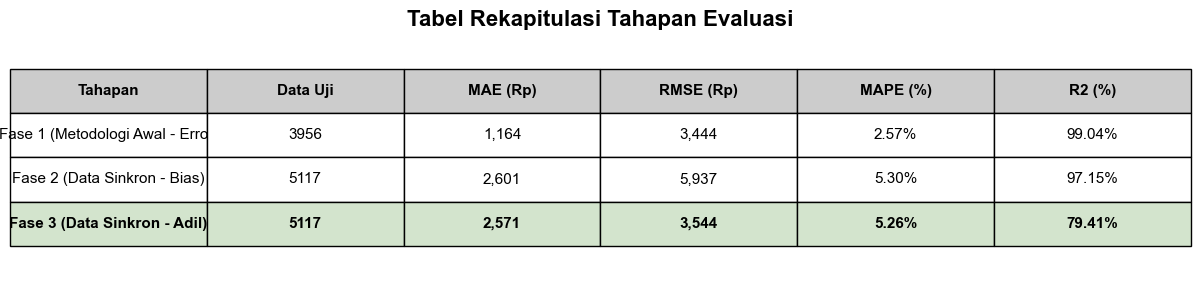

In [11]:
df_fase = pd.DataFrame([
    {'Tahapan': 'Fase 1 (Metodologi Awal - Error)', 'Data Uji': len(df_fase1), 'MAE (Rp)': f"{mae_1:,.0f}", 'RMSE (Rp)': f"{rmse_1:,.0f}", 'MAPE (%)': f"{mape_1:.2f}%", 'R2 (%)': f"{r2_1:.2f}%"},
    {'Tahapan': 'Fase 2 (Data Sinkron - Bias)', 'Data Uji': len(df_eval), 'MAE (Rp)': f"{mae_2:,.0f}", 'RMSE (Rp)': f"{rmse_2:,.0f}", 'MAPE (%)': f"{mape_2:.2f}%", 'R2 (%)': f"{r2_2:.2f}%"},
    {'Tahapan': 'Fase 3 (Data Sinkron - Adil)', 'Data Uji': len(df_eval), 'MAE (Rp)': f"{mae_3:,.0f}", 'RMSE (Rp)': f"{rmse_3:,.0f}", 'MAPE (%)': f"{mape_3:.2f}%", 'R2 (%)': f"{r2_3:.2f}%"}
])
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_fase.values, colLabels=df_fase.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

for (row, col), cell in table.get_celld().items():
    if row == 3:
        cell.set_facecolor('#d3e4cd')
        cell.set_text_props(weight='bold')
    elif row == 0:
        cell.set_facecolor('#cccccc')
        cell.set_text_props(weight='bold')

plt.title(f'Tabel Rekapitulasi Tahapan Evaluasi', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()